# **Forecasting Peak Yearly Electricity Demand in Bangladesh Vector Error Correction Model (VECM) and Fast Fourier Transformation(FFT)**



It is crucial to have a robust forecast of the peak yearly electricity demand for crafting a proper long-term development plan of electricity system for Bangadesh. However, it is often observed in various government plans to use a forecast that is done without applying proper time series econometrics and so raises questions about the robustness of the estimate. Those forecasts are often censured for jproviding exorbitant demand.


We have applied vector error correction model with exogenous variable (VECMX) model and Fast Fourier Transformation (FFT) to forecast till 2050.

  
**Data**
* From 1972 to 2024
* **Variables:** Peak Yearly Demand (MW), Real GDP (USD 2015 constant), Population, Urbanization rate, Yearly average surface temparature.
* **EV_dummy:** 1 for Year >=2021 and 0 Otherwise. Neither the actual number of EVs (Electric Cars and Rickshaws) nor the electricity demanded by them is not available for Bangladesh. This variable comes in the VECM model as an exogenous variable.


**Unit Root Test**
* We have applied Augmented Dickey–Fuller (ADF), DF-GLS, and KPSS tests.
* **I(1):** Peak Yearly Demand (MW), Real GDP (USD 2015 constant), Population
* **I(0):**  Urbanization rate, Yearly average surface temparature


**Johansen cointegration test**
* **No long run relationip** is found among  Peak Yearly Demand (MW), Real GDP, and Population
* However, **one a long-run relationship exists** between *Peak Yearly Demand (MW), Real GDP.*

**Models**
* **VECM:** Peak Yearly Demand (MW), and Real GDP
* **VECMX:** Peak Yearly Demand (MW), Real GDP, and EV_dummy
* **FFT:** Peak Yearly Demand(MW)

We found increase in demand due to EV adoption (VECMX- VECM).

The forecasted values of VECMX and FFT are found to be similar.



In [3]:
# @title
%pip install arch

   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   --------------------------------- ------ 786.4/934.4 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 934.4/934.4 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.3 MB 2.7 MB/s eta 0:00:14
   - -------------------------------------- 1.8/37.3 MB 3.2 MB/s eta 0:00:12
   --- ------------------------------------ 2.9/37.3 MB 3.7 MB/s eta 0:00:10
   ---- ----------------------------------- 3.9/37.3 MB 4.1 MB/s eta 0:00:09
   ----- ---------------------------------- 5.0/37.3 MB 4.4 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/37.3 MB 4.6 MB/s eta 0:00:07
   -------- ------------------------------- 8.1/37.3 MB 5.2 MB/s eta 0:00:06
   ----------- -----


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.vector_ar.vecm import select_order
from statsmodels.tsa.vector_ar.vecm import select_coint_rank
from statsmodels.tsa.stattools import adfuller,kpss
from arch.unitroot import DFGLS
from scipy.fft import fft, ifft

In [ ]:
Data = pd.read_excel("Demand Dataset (1972-2024) with loadsheeding.xlsx")
Data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Demand Forecasting (2025-2050)/Demand Dataset (1972-2024) with loadsheeding.xlsx'

In [ ]:
# @title
Data = Data[Data['Year'] != 2025]

In [ ]:
Data['Demand']=Data['Maximum_Demand_MW']
Data['ln_GDP']=np.log(Data['Real_GDP'])
Data['ln_Pop']=np.log(Data['Population'])
Data['ln_GDPpc']=np.log(Data['GDP_per_capita'])


F_data=Data[['Year','Demand','ln_GDP','ln_GDPpc','ln_Pop','Urban_Pop_share','Avg_yearly_temp']]
F_data.head()

,Year,Demand,ln_GDP,ln_GDPpc,ln_Pop,Urban_Pop_share,Avg_yearly_temp
0,1972,183,24.010058,4.474763,18.087185,8.086359,25.25871
1,1973,222,24.042774,4.697674,18.115816,8.487496,25.11027
2,1974,250,24.134368,5.105863,18.144128,8.956172,24.64588
3,1975,266,24.092627,5.520678,18.170350,9.634516,24.86207
4,1976,301,24.147696,4.841767,18.195727,10.551336,25.08366


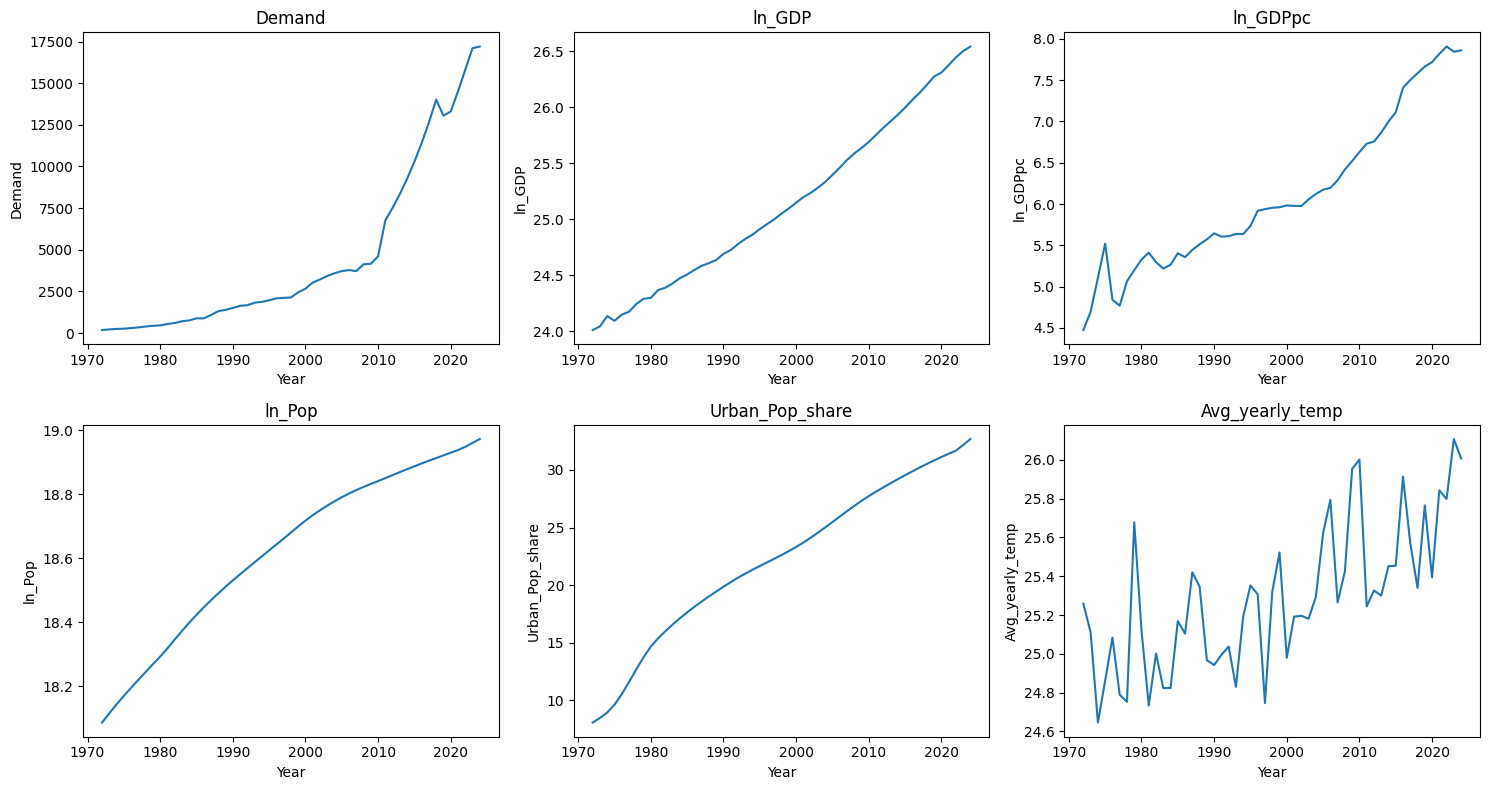

In [ ]:
# Exclude Year column
columns = [col for col in F_data.columns if col != "Year"]

n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, column in enumerate(columns):
    axes[i].plot(F_data["Year"], F_data[column])
    axes[i].set_title(column)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(column)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:


def unit_root_tests(series, name):
    results = {"Variable": name}

    # --- ADF (constant only) ---
    adf_c = adfuller(series, regression='c', autolag='AIC')
    results["ADF_c_stat"] = adf_c[0]
    results["ADF_c_p"] = adf_c[1]

    # --- ADF (constant + trend) ---
    adf_ct = adfuller(series, regression='ct', autolag='AIC')
    results["ADF_ct_stat"] = adf_ct[0]
    results["ADF_ct_p"] = adf_ct[1]

    # --- DFGLS (constant only) ---
    dfgls_c = DFGLS(series, trend='c')
    results["DFGLS_c_stat"] = dfgls_c.stat
    results["DFGLS_c_p"] = dfgls_c.pvalue

    # --- DFGLS (constant + trend) ---
    dfgls_ct = DFGLS(series, trend='ct')
    results["DFGLS_ct_stat"] = dfgls_ct.stat
    results["DFGLS_ct_p"] = dfgls_ct.pvalue

    # --- KPSS (constant only) ---
    kpss_c_stat, kpss_c_p, _, _ = kpss(series, regression='c', nlags="auto")
    results["KPSS_c_stat"] = kpss_c_stat
    results["KPSS_c_p"] = kpss_c_p

    # --- KPSS (constant + trend) ---
    kpss_ct_stat, kpss_ct_p, _, _ = kpss(series, regression='ct', nlags="auto")
    results["KPSS_ct_stat"] = kpss_ct_stat
    results["KPSS_ct_p"] = kpss_ct_p

    return results

In [ ]:
# Unit root test

results_list = []

for col in F_data.columns:
    if col != "Year":
        res = unit_root_tests(F_data[col].dropna(), col)
        results_list.append(res)

unit_root_table = pd.DataFrame(results_list)


/tmp/ipykernel_10617/1549449453.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_c_stat, kpss_c_p, _, _ = kpss(series, regression='c', nlags="auto")
/tmp/ipykernel_10617/1549449453.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ct_stat, kpss_ct_p, _, _ = kpss(series, regression='ct', nlags="auto")
/tmp/ipykernel_10617/1549449453.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_c_stat, kpss_c_p, _, _ = kpss(series, regression='c', nlags="auto")
/tmp/ipykernel_10617/1549449453.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The ac

In [ ]:
unit_root_table.round(4)

,Variable,ADF_c_stat,ADF_c_p,ADF_ct_stat,ADF_ct_p,DFGLS_c_stat,DFGLS_c_p,DFGLS_ct_stat,DFGLS_ct_p,KPSS_c_stat,KPSS_c_p,KPSS_ct_stat,KPSS_ct_p
0,Demand,4.1093,1.0000,2.4426,1.0000,-0.6776,0.4366,-2.5103,0.1146,0.9662,0.01,0.2713,0.01
1,ln_GDP,3.4454,1.0000,-0.8318,0.9629,-0.7289,0.4124,-1.9246,0.3395,1.1551,0.01,0.2968,0.01
2,ln_GDPpc,-0.3348,0.9204,-2.0695,0.5631,0.8731,0.9070,-2.3627,0.1560,1.1084,0.01,0.2463,0.01
3,ln_Pop,-2.7827,0.0608,-2.6585,0.2537,-0.1618,0.6352,-2.9558,0.0389,1.1368,0.01,0.2975,0.01
4,Urban_Pop_share,-3.2393,0.0178,-7.9746,0.0000,0.6549,0.8699,-4.2606,0.0005,1.1433,0.01,0.2174,0.01
5,Avg_yearly_temp,-1.1553,0.6925,-6.1087,0.0000,-1.3449,0.1714,-4.9058,0.0000,1.1694,0.01,0.1144,0.10


In [ ]:
# Selection of Optimal Lag

from statsmodels.tsa.api import VAR

# Only endogenous I(1) variables
Y = F_data[['Demand', 'ln_GDP']]

var_model = VAR(Y)
lag_order_results = var_model.select_order()
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        14.16       14.24   1.412e+06       14.19
1        3.186      3.432*       24.21       3.277
2        3.169       3.579       23.84       3.320
3        3.281       3.855       26.77       3.493
4        3.415       4.152       30.79       3.687
5        3.392       4.293       30.43       3.724
6        3.115       4.180       23.44       3.508
7        3.149       4.377       24.77       3.602
8        3.109       4.501       24.52       3.622
9        2.334       3.890      11.76*      2.908*
10      2.287*       4.008       11.82       2.922
--------------------------------------------------


In [ ]:
#Johansen Cointegration

from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen_test = coint_johansen(Y, det_order=0,k_ar_diff= 1)

# Results
print("Eigenvalues:", johansen_test.eig)
print("Trace statistic:", johansen_test.lr1)
print("Critical values (90%, 95%, 99%):")
print(johansen_test.cvt)

Eigenvalues: [0.33927005 0.00170123]
Trace statistic: [21.22175008  0.08683676]
Critical values (90%, 95%, 99%):
[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


### **Baseline: Vector Error Correction Model (VECM) with One Lag**

For two endogenous variables, the VECM system can be written as:

**Equation for Demand**

$$
\Delta Demand_t =
\alpha_1 EC_{t-1}
+ \gamma_{11}\Delta Demand_{t-1}
+ \gamma_{12}\Delta \ln(GDP)_{t-1}
+ \varepsilon_{1t}
$$

**Equation for GDP**

$$
\Delta \ln(GDP)_t =
\alpha_2 EC_{t-1}
+ \gamma_{21}\Delta Demand_{t-1}
+ \gamma_{22}\Delta \ln(GDP)_{t-1}
+ \varepsilon_{2t}
$$

**Cointegration (Long-Run Relationship)**

$$
EC_{t-1} =
Demand_{t-1}
- \beta \ln(GDP)_{t-1}
- c
$$

Where

- $\Delta$ = first difference  
- $EC_{t-1}$ = error correction term (deviation from long-run equilibrium)  
- $\alpha$ = speed of adjustment toward equilibrium  
- $\gamma$ = short-run dynamic coefficients (lag effects)  
- $\beta$ = long-run relationship parameter  
- $c$ = constant  
- $\varepsilon_t$ = error term

In [ ]:
from statsmodels.tsa.vector_ar.vecm import VECM

vecm_model = VECM(
    endog=Y,
    k_ar_diff=1,        # from VAR lag selection
    coint_rank=1,       # from Johansen
    deterministic='ci'  # constant in cointegration
)

vecm_res = vecm_model.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Demand
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.Demand      0.3768      0.129      2.912      0.004       0.123       0.630
L1.ln_GDP  -1312.8020   3574.970     -0.367      0.713   -8319.615    5694.011
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_GDP
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.Demand   7.199e-06   4.51e-06      1.596      0.110   -1.64e-06     1.6e-05
L1.ln_GDP     -0.4952      0.125     -3.974      0.000      -0.739      -0.251
               Loading coefficients (alpha) for equation Demand               
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [ ]:

# Run prediction once
forecast, lower, upper = vecm_res.predict(steps=26, alpha=0.05)

# Extract Demand (first column) and convert to thousand MW
demand_forecast = forecast[:,0]
demand_lower = lower[:,0]
demand_upper = upper[:,0]
# Create years (adjust start year if needed)
start_year = 2025
years = list(range(start_year, start_year + 26))

# Create dataframe
df_forecast = pd.DataFrame({
    "Year": years,
    "Forecast_Baseline": demand_forecast,
    "Lower CI": demand_lower,
    "Upper CI": demand_upper
})

# Select specific years
years_of_interest = [2030, 2035, 2040, 2045, 2050]
table = df_forecast[df_forecast["Year"].isin(years_of_interest)]



In [ ]:
table

,Year,Forecast_Baseline,Lower CI,Upper CI
5,2030,19840.126450,16761.738598,22918.514302
10,2035,22324.649197,18064.815070,26584.483323
15,2040,24934.753452,19836.201551,30033.305353
20,2045,27676.373146,21929.682008,33423.064284
25,2050,30556.128850,24291.506365,36820.751335


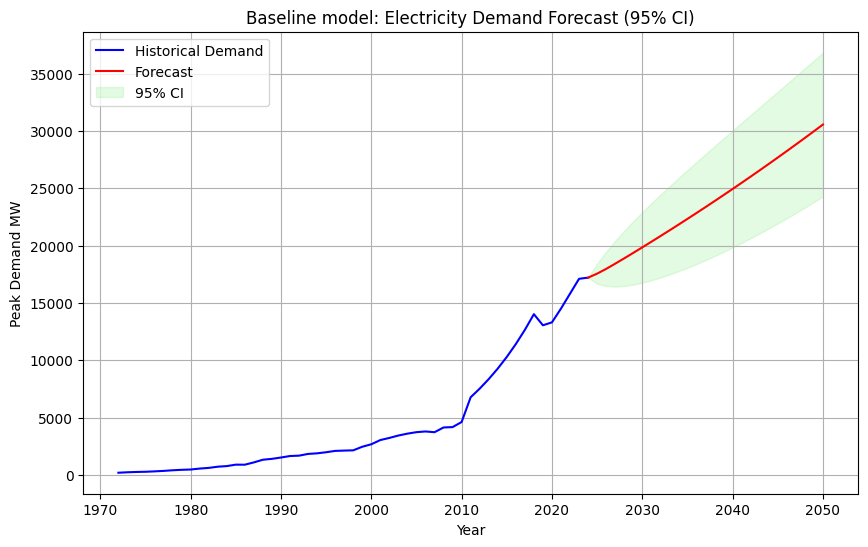

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Historical data
years_hist = F_data['Year']
demand_hist = F_data['Demand']

# Forecast data
forecast, lower, upper = vecm_res.predict(steps=26, alpha=0.05)
years_forecast = np.arange(years_hist.iloc[-1]+1, years_hist.iloc[-1]+1+26)

# Include the last historical point in the forecast line
forecast_line_years = np.concatenate([[years_hist.iloc[-1]], years_forecast])
forecast_line_values = np.concatenate([[demand_hist.iloc[-1]], forecast[:,0]])

# Same for confidence interval (start from last historical point)
lower_line = np.concatenate([[demand_hist.iloc[-1]], lower[:,0]])
upper_line = np.concatenate([[demand_hist.iloc[-1]], upper[:,0]])

# Plot
plt.figure(figsize=(10,6))

# Historical line (up to last observed year)
plt.plot(years_hist, demand_hist, color='blue', label='Historical Demand')

# Forecast line (including last historical point for continuity)
plt.plot(forecast_line_years, forecast_line_values, color='red', label='Forecast')

# Confidence interval
plt.fill_between(forecast_line_years, lower_line, upper_line, color='lightgreen', alpha=0.25, label='95% CI')

# Labels, title, legend
plt.xlabel('Year')
plt.ylabel('Peak Demand MW')
plt.title('Baseline model: Electricity Demand Forecast (95% CI)')
plt.legend()
plt.grid(True)
plt.show()


### **Vector Error Correction Model with Exogenous Variable (VECMX)**

When an exogenous variable (EV_dummy) is included, the model becomes:
Equation for Demand

$$
\Delta Demand_t =
\alpha_1 EC_{t-1}
+ \gamma_{11}\Delta Demand_{t-1}
+ \gamma_{12}\Delta \ln(GDP)_{t-1}
+ \delta_1 EV\_dummy_t
+ \varepsilon_{1t}
$$

Equation for GDP

$$
\Delta \ln(GDP)_t =
\alpha_2 EC_{t-1}
+ \gamma_{21}\Delta Demand_{t-1}
+ \gamma_{22}\Delta \ln(GDP)_{t-1}
+ \delta_2 EV\_dummy_t
+ \varepsilon_{2t}
$$

Cointegration (Long-Run Relationship)

$$
EC_{t-1} =
Demand_{t-1}
- \beta \ln(GDP)_{t-1}
- c
$$


 Where

- $\Delta$ = first difference  
- $EC_{t-1}$ = error correction term (long-run disequilibrium)  
- $\alpha$ = speed of adjustment toward equilibrium  
- $\gamma$ = short-run dynamic coefficients  
- $\delta$ = effect of the exogenous variable  
- $EV\_dummy$ = dummy variable capturing EV adoption  
- $\beta$ = long-run relationship coefficient  
- $c$ = constant  
- $\varepsilon_t$ = error term

In [ ]:
# creating the EV dummy
Data["EV_dummy"] = (Data["Year"] >= 2021).astype(int)
# Endogenous Variable
X=Data[["EV_dummy"]]


In [ ]:
# Fitting the VECMX
model = VECM(endog=Y, exog=X, k_ar_diff=1, coint_rank=1, deterministic='ci')
vecm_s1_res = model.fit()

print(vecm_s1_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Demand
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
exog1        371.3562    252.306      1.472      0.141    -123.155     865.868
L1.Demand      0.2971      0.136      2.191      0.028       0.031       0.563
L1.ln_GDP   -767.1364   3541.237     -0.217      0.828   -7707.834    6173.561
Det. terms outside the coint. relation & lagged endog. parameters for equation ln_GDP
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
exog1         -0.0157      0.009     -1.774      0.076      -0.033       0.002
L1.Demand   7.355e-06   4.75e-06      1.549      0.121   -1.95e-06    1.67e-05
L1.ln_GDP     -0.5251      0.124     -4.236      0.000      -0.768      -0.282
               Loading coefficients (a

In [ ]:
future_EV = np.ones((26,1))

forecast1, lower1, upper1 = vecm_s1_res.predict(steps=26, alpha=0.05,exog_fc=future_EV)

# Extract Demand (first column) and convert to thousand MW
demand_forecast1 = forecast1[:,0]
demand_lower1 = lower1[:,0]
demand_upper1 = upper1[:,0]
# Create years (adjust start year if needed)
start_year = 2025
years = list(range(start_year, start_year + 26))

# Create dataframe
df_forecast1 = pd.DataFrame({
    "Year": years,
    "Forecast_EV": demand_forecast1,
    "Lower CI": demand_lower1,
    "Upper CI": demand_upper1
})

# Select specific years
years_of_interest = [2030, 2035, 2040, 2045, 2050]
table1 = df_forecast1[df_forecast1["Year"].isin(years_of_interest)]

table1


,Year,Forecast_EV,Lower CI,Upper CI
5,2030,22695.607417,19909.546706,25481.668128
10,2035,27659.268421,23794.639665,31523.897178
15,2040,32715.730600,28034.447655,37397.013544
20,2045,37871.065091,32514.764520,43227.365662
25,2050,43131.912906,37194.446735,49069.379077


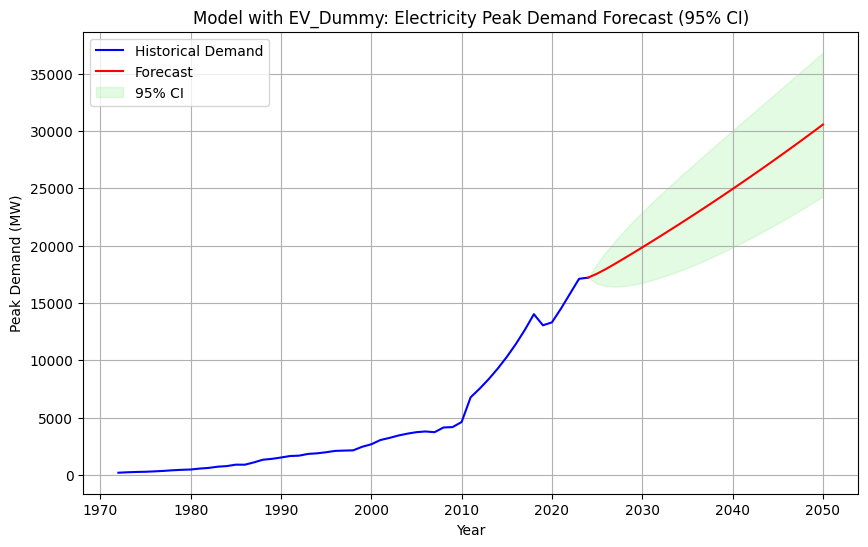

In [ ]:

# Historical data
years_hist = F_data['Year']
demand_hist = F_data['Demand']

# Forecast data
forecast1, lower1, upper1 = vecm_s1_res.predict(steps=26, alpha=0.05,exog_fc=future_EV)
years_forecast = np.arange(years_hist.iloc[-1]+1, years_hist.iloc[-1]+1+26)

# Include the last historical point in the forecast line
forecast_line_years = np.concatenate([[years_hist.iloc[-1]], years_forecast])
forecast_line_values = np.concatenate([[demand_hist.iloc[-1]], forecast[:,0]])

# Same for confidence interval (start from last historical point)
lower_line = np.concatenate([[demand_hist.iloc[-1]], lower[:,0]])
upper_line = np.concatenate([[demand_hist.iloc[-1]], upper[:,0]])

# Plot
plt.figure(figsize=(10,6))

# Historical line (up to last observed year)
plt.plot(years_hist, demand_hist, color='blue', label='Historical Demand')

# Forecast line (including last historical point for continuity)
plt.plot(forecast_line_years, forecast_line_values, color='red', label='Forecast')

# Confidence interval
plt.fill_between(forecast_line_years, lower_line, upper_line, color='lightgreen', alpha=0.25, label='95% CI')

# Labels, title, legend
plt.xlabel('Year')
plt.ylabel('Peak Demand (MW)')
plt.title('Model with EV_Dummy: Electricity Peak Demand Forecast (95% CI)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd

# This merges the two tables where the 'Year' values match
merged_df = pd.merge(table, table1, on='Year', how='inner')



In [ ]:
merged_df

,Year,Forecast_Baseline,Lower CI_x,Upper CI_x,Forecast_EV,Lower CI_y,Upper CI_y
0,2030,19840.126450,16761.738598,22918.514302,22695.607417,19909.546706,25481.668128
1,2035,22324.649197,18064.815070,26584.483323,27659.268421,23794.639665,31523.897178
2,2040,24934.753452,19836.201551,30033.305353,32715.730600,28034.447655,37397.013544
3,2045,27676.373146,21929.682008,33423.064284,37871.065091,32514.764520,43227.365662
4,2050,30556.128850,24291.506365,36820.751335,43131.912906,37194.446735,49069.379077


# **Impact of EV (VECMX forecast - VECM forecast)**

In [ ]:
# impact of EV
merged_df['impact'] =merged_df['Forecast_EV']- merged_df['Forecast_Baseline']
merged_df[['Year','impact']]

,Year,impact
0,2030,2855.480967
1,2035,5334.619225
2,2040,7780.977147
3,2045,10194.691945
4,2050,12575.784056


#**Fast Fourier Transformation**

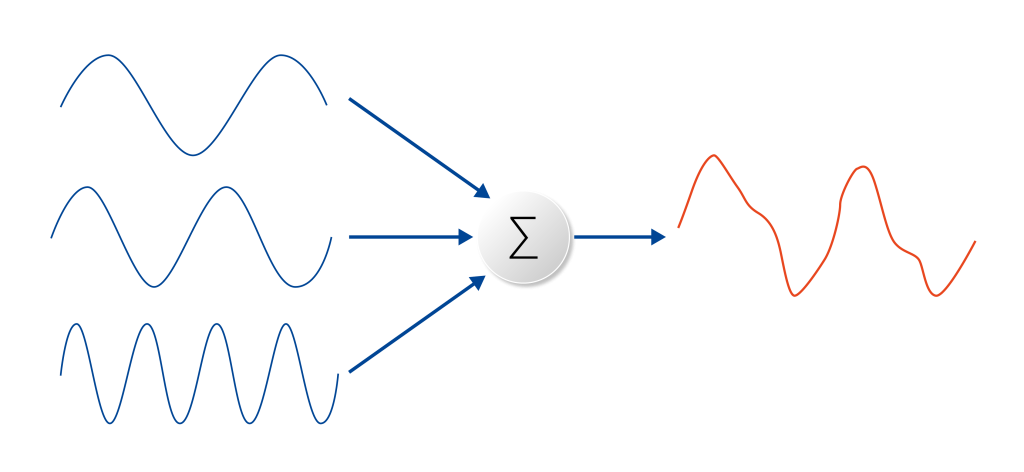



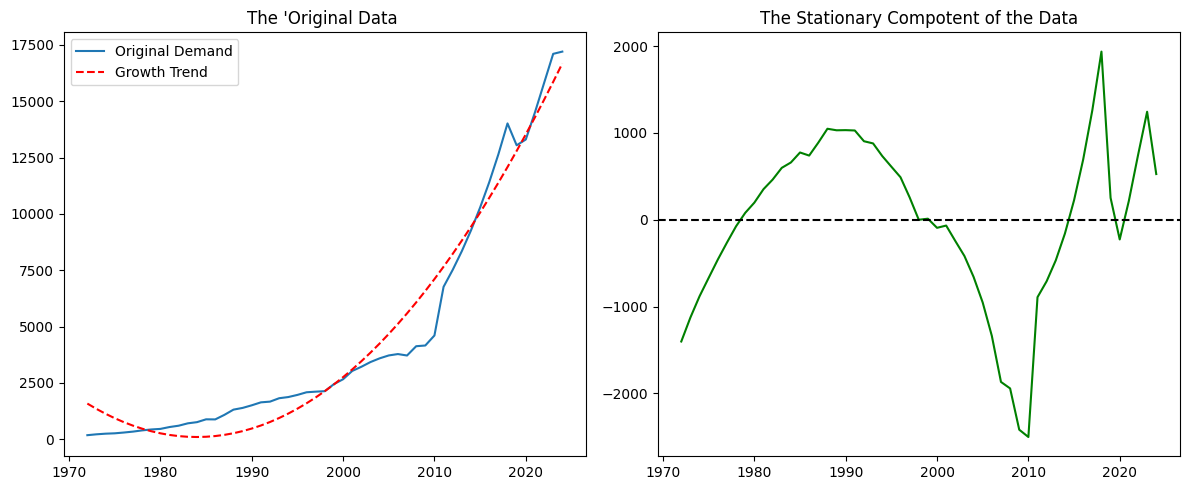

In [ ]:
years = Data['Year'].values
demand = Data['Maximum_Demand_MW'].values

# 2. Calculate the Growth Trend (Polynomial Fit)
# This finds the "Average" path the demand is taking upward
coeffs = np.polyfit(years, demand, 2)
trend = np.polyval(coeffs, years)

# 3. Create "Stationary" Data (The Residuals)
# We subtract the trend from the actual demand
residuals = demand - trend

# 4. Visualize the "Flattened" data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(years, demand, label='Original Demand')
plt.plot(years, trend, 'r--', label='Growth Trend')
plt.title("The 'Original Data ")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(years, residuals, color='green')
plt.axhline(0, color='black', linestyle='--')
plt.title("The Stationary Compotent of the Data")

plt.tight_layout()
plt.show()

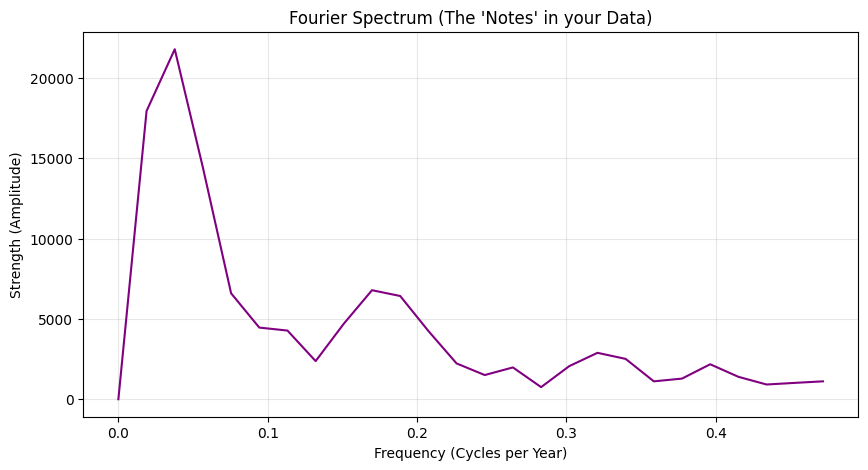

In [ ]:
from scipy.fft import fft

ffthreshold = 0 # We will filter later

# 1. Perform the Fourier Transform
# This converts the stationary Data into Frequency
n = len(residuals)
f_values = fft(residuals)
frequencies = np.fft.fftfreq(n)

# 2. Calculate Amplitude
# Fourier gives complex numbers; 'abs' gives us the strength (Volume) of each note
amplitudes = np.abs(f_values)

# 3. Visualize the "Spectrum"
# We only look at positive frequencies (the right side of the graph)
plt.figure(figsize=(10, 5))
plt.plot(frequencies[:n//2], amplitudes[:n//2], color='purple')
plt.title("Fourier Spectrum (The 'Notes' in your Data)")
plt.xlabel("Frequency (Cycles per Year)")
plt.ylabel("Strength (Amplitude)")
plt.grid(True, alpha=0.3)
plt.show()

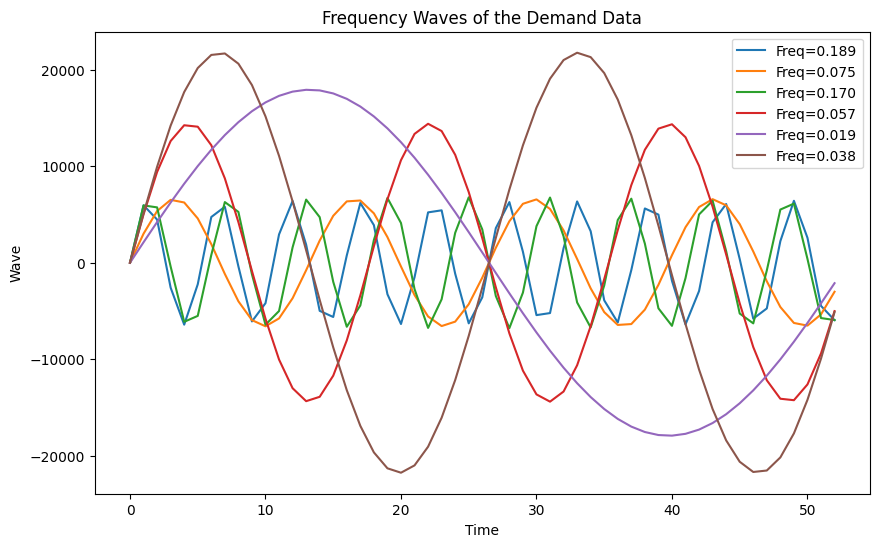

In [ ]:


# FFT
n = len(residuals)
f_values = fft(residuals)
frequencies = np.fft.fftfreq(n)

amplitudes = np.abs(f_values)

# Keep positive frequencies
mask = frequencies > 0
freqs = frequencies[mask]
amps = amplitudes[mask]

# Select top 3 dominant frequencies
top_indices = np.argsort(amps)[-6:]

t = np.arange(n)

plt.figure(figsize=(10,6))

for idx in top_indices:
    freq = freqs[idx]
    amp = amps[idx]

    wave = amp * np.sin(2*np.pi*freq*t)

    plt.plot(t, wave, label=f"Freq={freq:.3f}")

plt.title("Frequency Waves of the Demand Data")
plt.xlabel("Time")
plt.ylabel("Wave")
plt.legend()
plt.show()

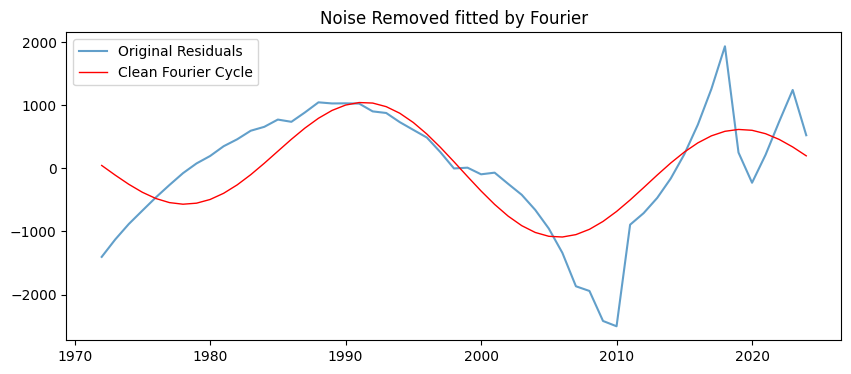

In [ ]:
# 1. Identify the top 3 strongest cycles
# We sort the amplitudes and keep the top indices
top_indices = np.argsort(amplitudes)[::-1][:3]

# 2. Create a "Clean" version of the Fourier data
# We start with zeros and only put back the "Strong" notes
clean_f_values = np.zeros_like(f_values)
for idx in top_indices:
    clean_f_values[idx] = f_values[idx]

# 3. Turn it back into a wave (Inverse Fourier Transform)
clean_cycles = np.fft.ifft(clean_f_values).real

# 4. Compare Clean vs Messy
plt.figure(figsize=(10, 4))
plt.plot(years, residuals, label='Original Residuals', alpha=0.7)
plt.plot(years, clean_cycles, label='Clean Fourier Cycle', color='red', linewidth=1)
plt.title("Noise Removed fitted by Fourier")
plt.legend()
plt.show()

In [ ]:
# --- Confidence Interval Calculation ---
# 1. Calculate historical residuals to find the 'error' in the model
forecast_horizon = 25
future_years = np.arange(years[-1] + 1, years[-1] + forecast_horizon + 1)
all_years = np.concatenate([years, future_years])
full_trend = np.polyval(coeffs, all_years)


# 3. Extend the Fourier Cycles
def repeat_pattern(pattern, target_length):
    # This repeats the established cycle over the new time horizon
    return np.array([pattern[i % len(pattern)] for i in range(target_length)])


full_cycles = repeat_pattern(clean_cycles, len(all_years))


historical_fit = full_trend[:len(years)] + full_cycles[:len(years)]
residuals = demand - historical_fit
std_dev = np.std(residuals)

final_forecast = full_trend + full_cycles

# 2. Define the Confidence Interval (95% uses 1.96 multiplier)
ci_upper = final_forecast + (1.96 * std_dev)
ci_lower = final_forecast - (1.96 * std_dev)


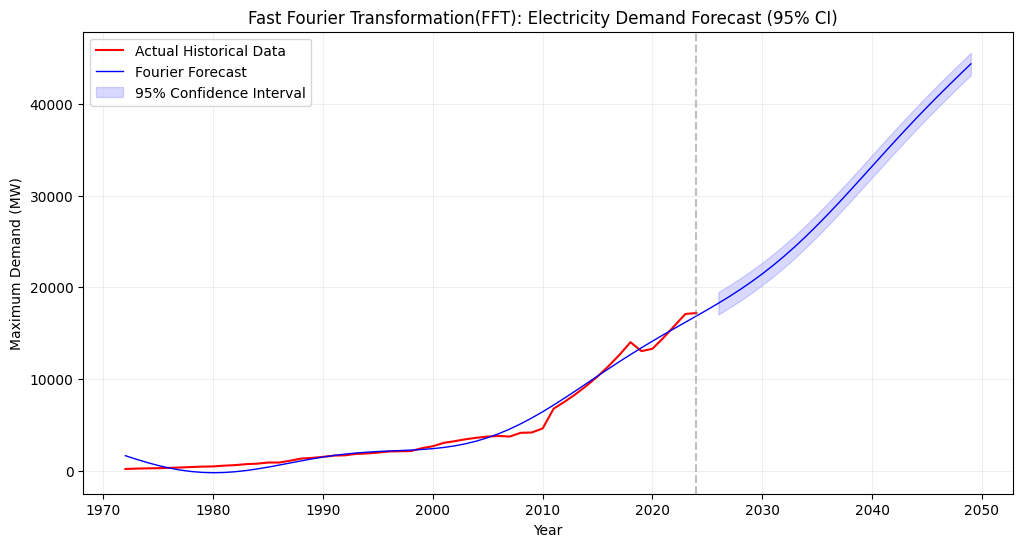

In [ ]:

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot Historical Data
plt.plot(years, demand, color='red', label='Actual Historical Data')

# Plot Forecast Line
plt.plot(all_years, final_forecast, color='blue', linewidth=1, label='Fourier Forecast')

# Add Confidence Interval shading for the future range (2026-2050)
# We filter the indices to only shade the future years
future_mask = all_years >= 2026
plt.fill_between(all_years[future_mask],
                 ci_lower[future_mask],
                 ci_upper[future_mask],
                 color='blue', alpha=0.15, label='95% Confidence Interval')

plt.axvline(x=2024, color='gray', linestyle='--', alpha=0.5)
plt.title("Fast Fourier Transformation(FFT): Electricity Demand Forecast (95% CI)  ")
plt.xlabel("Year")
plt.ylabel("Maximum Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


In [ ]:

# --- Data Table with Bounds ---
forecast_fft = pd.DataFrame({
    'Year': all_years[future_mask],
    'Forecast_FFT': final_forecast[future_mask],
    'Lower_CI': ci_lower[future_mask],
    'Upper_CI': ci_upper[future_mask]
})

print(forecast_fft.head(25))

In [ ]:
years_of_interest = [2030, 2035, 2040, 2045, 2050]
table2 = forecast_fft[forecast_fft["Year"].isin(years_of_interest)]
table2

,Year,Forecast_FFT,Lower_CI,Upper_CI
4,2030,21473.269213,20250.297085,22696.241340
9,2035,26774.036250,25551.064122,27997.008377
14,2040,33211.640638,31988.668511,34434.612765
19,2045,39662.321859,38439.349732,40885.293987


In [ ]:
# To compare values of VECMX and FFT
import pandas as pd
# This merges the two tables where the 'Year' values match
merged_df1 = pd.merge(table1,table2 ,on='Year', how='inner')


#**Comparison of VECMX and FFT forecast**

In [ ]:
merged_df1

,Year,Forecast_EV,Lower CI,Upper CI,Forecast_FFT,Lower_CI,Upper_CI
0,2030,22695.607417,19909.546706,25481.668128,21473.269213,20250.297085,22696.241340
1,2035,27659.268421,23794.639665,31523.897178,26774.036250,25551.064122,27997.008377
2,2040,32715.730600,28034.447655,37397.013544,33211.640638,31988.668511,34434.612765
3,2045,37871.065091,32514.764520,43227.365662,39662.321859,38439.349732,40885.293987


# **Diagnostic Tests for VECM and VECMX model**
* Normality test
* white noise test

#Normality test

In [ ]:
resi_VECM = vecm_res.resid
resi_VECMX = vecm_s1_res.resid

In [ ]:
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(resi_VECM)
print("JB Statistic:", jb_stat)
print("p-value:", jb_pvalue)

JB Statistic: [79.9330434  30.33886475]
p-value: [4.39298949e-18 2.58225558e-07]


In [ ]:

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(resi_VECMX)
print("JB Statistic:", jb_stat)
print("p-value:", jb_pvalue)

JB Statistic: [100.28080884  29.76935922]
p-value: [1.67609658e-22 3.43293659e-07]


Residulas are not normally distributed in any model.

In [ ]:
# white noise test

white_noise_VECM = vecm_res.test_whiteness(nlags=10)
white_noise_VECMX = vecm_s1_res.test_whiteness(nlags=10)


# White noise test

In [ ]:
print(white_noise_VECM.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         23.39          48.60   0.914 34
----------------------------------------


In [ ]:
print(white_noise_VECMX.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         24.10          48.60   0.896 34
----------------------------------------


No serial correlation was found in the residulas of any model.